In [ ]:
import sys, os
_ROOT = os.path.abspath(os.path.join(os.getcwd(), '../..'))  # scrape_code/
sys.path.insert(0, os.path.join(_ROOT, 'utils'))

# Notebook for doing a statistical and analysis deep dive into La Rochelle 

In [ ]:
import pandas as pd
import requests
import numpy as np
import json, os, time, pdb
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
sns.set_theme()

from util_data_funcs import *

_FD = os.path.join(_ROOT, 'formed_data')

file_dir = os.listdir(os.path.join(_FD, 'game_data'))
player_file_dir = os.listdir(os.path.join(_FD, 'player_data_mk2'))
team_file_dir = os.listdir(os.path.join(_FD, 'team_data'))

league_dict = {
    'URC': [
        [os.path.join(_FD, 'game_data', i) for i in file_dir if 'URC_game' in i],
        [os.path.join(_FD, 'player_data_mk2', i) for i in player_file_dir if 'URC_player' in i],
        [os.path.join(_FD, 'team_data', i) for i in team_file_dir if 'URC_team' in i]
    ],
    'Prem': [
        [os.path.join(_FD, 'game_data', i) for i in file_dir if 'Prem_game' in i],
        [os.path.join(_FD, 'player_data_mk2', i) for i in player_file_dir if 'Prem_player' in i],
        [os.path.join(_FD, 'team_data', i) for i in team_file_dir if 'Prem_team' in i]
    ],
    'T14': [
        [os.path.join(_FD, 'game_data', i) for i in file_dir if 'T14_game' in i],
        [os.path.join(_FD, 'player_data_mk2', i) for i in player_file_dir if 'T14_player' in i],
        [os.path.join(_FD, 'team_data', i) for i in team_file_dir if 'T14_team' in i]
    ],
    'RWC': [],
    'RChamp': [
        [os.path.join(_FD, 'game_data', i) for i in file_dir if 'RChamp_game' in i],
        [os.path.join(_FD, 'player_data_mk2', i) for i in player_file_dir if 'RChamp_player' in i],
        [os.path.join(_FD, 'team_data', i) for i in team_file_dir if 'RChamp_team' in i]
    ],
    'SixNat': [
        [os.path.join(_FD, 'game_data', i) for i in file_dir if 'SixNat_game' in i],
        [os.path.join(_FD, 'player_data_mk2', i) for i in player_file_dir if 'SixNat_player' in i],
        [os.path.join(_FD, 'team_data', i) for i in team_file_dir if 'SixNat_team' in i]
    ],
    'SR': [
        [os.path.join(_FD, 'game_data', i) for i in file_dir if 'SR_game' in i],
        [os.path.join(_FD, 'player_data_mk2', i) for i in player_file_dir if 'SR_player' in i],
        [os.path.join(_FD, 'team_data', i) for i in team_file_dir if 'SR_team' in i]
    ],
    'PNCup': []
}

grab_files = lambda league, order: pd.concat(list(map(pd.read_csv, league_dict[league][order])))

In [3]:
t14_game_df, t14_player_df, t14_team_df = data_combine(
    grab_files('T14', 0),
    grab_files('T14', 1),
    grab_files('T14', 2)
)
urc_game_df, urc_player_df, urc_team_df = data_combine(
    grab_files('URC', 0),
    grab_files('URC', 1),
    grab_files('URC', 2)
)

data_concat = calc_custom_metrics(pd.concat([
    fill_pos(urc_player_df, 'URC'),
    fill_pos(t14_player_df, 'T14')
]))

six_nat_game_df, six_nat_player_df, six_nat_team_df = data_combine_temp_inter(
    grab_files('SixNat', 0),
    grab_files('SixNat', 1),
    grab_files('SixNat', 2)
)
six_nat_player_concat = calc_custom_metrics(fill_pos(six_nat_player_df, 'SixNat'))

rchamp_game_df, rchamp_player_df, rchamp_team_df = data_combine_temp_inter(
    grab_files('RChamp', 0),
    grab_files('RChamp', 1),
    grab_files('RChamp', 2)
)
rchamp_player_concat = calc_custom_metrics(fill_pos(rchamp_player_df, 'RChamp'))

/home/colingrosh/Desktop/sports_analytics/code/rugby_v2/Rugby_DB_Analysis/scrape_code/util_data_funcs.py:112: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['passes_per_runs'].fillna(0.0, inplace=True)
/home/colingrosh/Desktop/sports_analytics/code/rugby_v2/Rugby_DB_Analysis/scrape_code/util_data_funcs.py:113: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the 

In [3]:
data_concat.columns

Index(['p_name', 'position', 'p_id', 'team', 'tries', 'try_assists',
       'conversion_goals', 'penalty_goals', 'drop_goals_converted', 'points',
       '-', 'passes', 'runs', 'meters_run', 'clean_breaks', 'defenders_beaten',
       'offloads', 'to_conceded', 'tackles', 'missed_tackles', 'lineouts_won',
       'penalties_conceded', 'yellows', 'reds', 'game_id', 'league_df',
       'season', 'team_name', 'team_id', 'rank', 'alt_position',
       'off_position', 'pos_place', 'league', 'meters_per_passes',
       'adj_meters_per_passes', 'passes_per_runs'],
      dtype='object')

In [4]:
data_concat.head()

,p_name,position,p_id,team,tries,try_assists,conversion_goals,penalty_goals,drop_goals_converted,points,...,team_name,team_id,rank,alt_position,off_position,pos_place,league,meters_per_passes,adj_meters_per_passes,passes_per_runs
0,S Zebo,FB,11186,25925,0.0,0.0,0.0,0.0,0.0,0.0,...,Munster,25925.0,5.0,W,FB,back,URC,8.5,0.85,0.60
1,C Nash,W,24804,25925,0.0,0.0,0.0,0.0,0.0,0.0,...,Munster,25925.0,5.0,W,W,back,URC,10.0,2.00,0.40
2,A Frisch,C,37547,25925,0.0,0.0,0.0,0.0,0.0,0.0,...,Munster,25925.0,5.0,C,C,back,URC,0.0,0.00,1.50
3,A Nankivell,C,23613,25925,0.0,0.0,0.0,0.0,0.0,0.0,...,Munster,25925.0,5.0,C,C,back,URC,13.0,3.25,0.25
4,S Daly,W,24006,25925,0.0,0.0,0.0,0.0,0.0,0.0,...,Munster,25925.0,5.0,W,W,back,URC,52.0,13.00,0.25


In [5]:
la_roch = 119318
lr_df = data_concat[data_concat['team_id'] == la_roch]
# lr_df = data_concat[data_concat['team_name'] == 'Stade Toulousain']

# Split out the forwards and backs 
lr_forwards, lr_backs = lr_df[lr_df['pos_place'] == 'forward'], \
                lr_df[lr_df['pos_place'] == 'back']

# Aggregate the Six Nations and Rugby Championship 
euro_cap_count = six_nat_player_concat.groupby(['p_name', 'p_id'])['game_id'].nunique().reset_index().rename(columns={'game_id': 'cap_count'})
south_hemp_cap_count = rchamp_player_concat.groupby(['p_name', 'p_id'])['game_id'].nunique().reset_index().rename(columns={'game_id': 'cap_count'})
total_caps = pd.concat([euro_cap_count, south_hemp_cap_count], axis=0)

# Join in the international data to get player caps 
lr_w_caps =  lr_df.merge(total_caps, how='left', on=['p_name', 'p_id'])
lr_w_caps['cap_count'] = lr_w_caps['cap_count'].fillna(0.0)

# Grouping the player averages and season position averages 
lr_play_avg = lr_w_caps.groupby(
    ['season', 'p_id', 'p_name', 'pos_place']
)['runs', 'meters_per_passes', 'adj_meters_per_passes', 'passes_per_runs', 'meters_run', 'passes'].mean().reset_index()

lr_total_avg = lr_df.groupby(
    ['season', 'pos_place']
)['runs', 'meters_per_passes', 'adj_meters_per_passes', 'passes_per_runs', 'meters_run', 'passes'].mean().reset_index().rename(
    columns={
        'meters_per_passes':'player_avg_mpp',
        'adj_meters_per_passes':'player_avg_adj_mpp',
        'passes_per_runs': 'player_avg_ppr', 
        'meters_run': 'player_meters_run_avg',
        'passes': 'player_passes_avg'
    }
)

# Merge the position averages to the player averages 
lr_forward_avgs = lr_play_avg[lr_play_avg['pos_place'] == 'forward'].merge(
    lr_total_avg[lr_total_avg['pos_place'] == 'forward'], on=['season'], how='left'
)
lr_back_avgs = lr_play_avg[lr_play_avg['pos_place'] == 'back'].merge(
    lr_total_avg[lr_total_avg['pos_place'] == 'back'], on=['season'], how='left'
)

lr_forward_overs = lr_forward_avgs[
    (lr_forward_avgs['meters_per_passes'] >= lr_forward_avgs['player_avg_mpp']) | \
    (lr_forward_avgs['adj_meters_per_passes'] >= lr_forward_avgs['player_avg_adj_mpp']) | \
    (lr_forward_avgs['passes_per_runs'] >= lr_forward_avgs['player_avg_ppr'])]

lr_back_overs = lr_back_avgs[
    (lr_back_avgs['meters_per_passes'] >= lr_back_avgs['player_avg_mpp']) | \
    (lr_back_avgs['adj_meters_per_passes'] >= lr_back_avgs['player_avg_adj_mpp']) | \
    (lr_back_avgs['passes_per_runs'] >= lr_back_avgs['player_avg_ppr'])]

/home/cgrosh/anaconda3/envs/sports_env/lib/python3.7/site-packages/ipykernel_launcher.py:21: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
/home/cgrosh/anaconda3/envs/sports_env/lib/python3.7/site-packages/ipykernel_launcher.py:25: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.


In [6]:
for_diamonds = [24593, 33102, 22477, 10100]
for_known_stars = [29456, 20593]

/home/cgrosh/anaconda3/envs/sports_env/lib/python3.7/site-packages/ipykernel_launcher.py:8: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  
/home/cgrosh/anaconda3/envs/sports_env/lib/python3.7/site-packages/ipykernel_launcher.py:10: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  # Remove the CWD from sys.path while we load stuff.


[-0.571729490022173, 0.1766075388026607, 0.9249445676274943, 1.673281596452328, 2.4216186252771617, 3.169955654101995, 3.918292682926829, 4.666629711751663, 5.414966740576496, 6.16330376940133, 6.911640798226164]


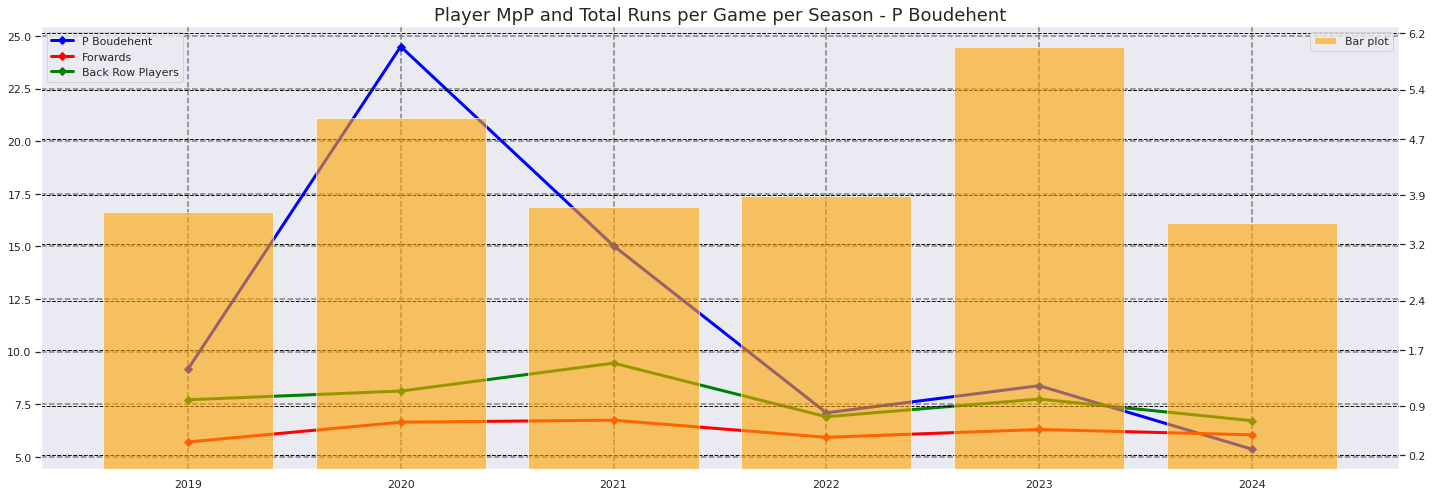

In [7]:
fig, axes = plt.subplots(1, 1,  figsize=(20, 7)) 

player_id = 33102
player_name = lr_forward_avgs[lr_forward_avgs['p_id'] == player_id]['p_name'].iloc[0]
metric_use = 'meters_per_passes'

p_boud = lr_forward_avgs[lr_forward_avgs['p_id'] == player_id]
all_for = lr_forward_overs.groupby('season')['meters_per_passes', 'adj_meters_per_passes'].mean().reset_index()
back_row = lr_df[lr_df['off_position'].isin(['FL', 'N8'])].groupby('season')[
    'meters_per_passes', 'adj_meters_per_passes'
].mean().reset_index()

axes.plot(p_boud['season'], p_boud[metric_use], color='blue', marker='D', linewidth=3.0, zorder=3)
axes.plot(all_for['season'], all_for[metric_use], color='red', marker='D', linewidth=3.0, zorder=3)
axes.plot(back_row['season'], back_row[metric_use], color='green', marker='D', linewidth=3.0, zorder=3)

ylim1 = axes.get_ylim()
len1 = ylim1[1]-ylim1[0]
yticks1 = axes.get_yticks()
rel_dist = [(y-ylim1[0])/len1 for y in yticks1]

ax2 = axes.twinx()
ax2.bar(p_boud['season'], p_boud['runs_x'], alpha=0.6, color='orange', label='Bar plot', zorder=1)

ylim2 = ax2.get_ylim()
len2 = ylim2[1]-ylim2[0]
yticks2 = [ry*len2+ylim2[0] for ry in rel_dist]

print(yticks2)

ax2.set_yticks(np.around(yticks2, decimals=1))
ax2.set_ylim(ylim2)  #<-- this line is needed to re-adjust the limits to the original values
axes.yaxis.grid(which="major", color='black', linestyle='-')
ax2.yaxis.grid(which="major", color='black', linestyle='--')
ax2.legend(loc='upper right')


axes.grid(True, which='both', color='grey', linestyle='--', linewidth=1.5, zorder=0)
axes.legend([player_name, 'Forwards', 'Back Row Players'], loc='upper left')

axes.set_title('Player MpP and Total Runs per Game per Season - {}'.format(player_name), fontsize=18)

plt.tight_layout()
plt.show()


/home/cgrosh/anaconda3/envs/sports_env/lib/python3.7/site-packages/ipykernel_launcher.py:8: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  
/home/cgrosh/anaconda3/envs/sports_env/lib/python3.7/site-packages/ipykernel_launcher.py:10: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  # Remove the CWD from sys.path while we load stuff.


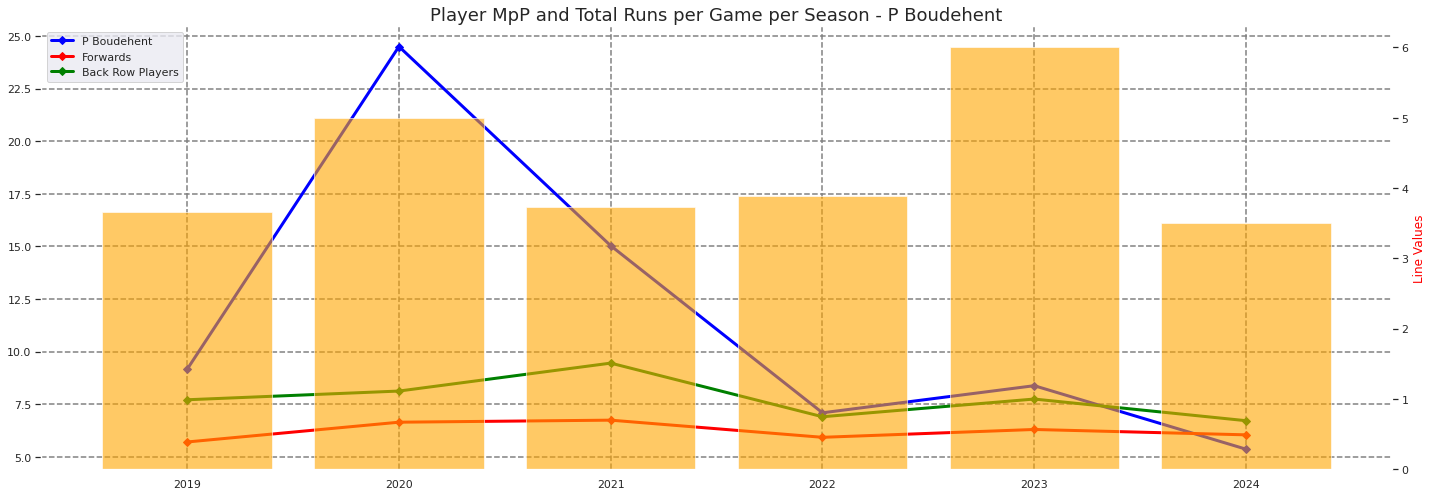

In [8]:
fig, axes = plt.subplots(1, 1,  figsize=(20, 7)) 

player_id = 33102
player_name = lr_forward_avgs[lr_forward_avgs['p_id'] == player_id]['p_name'].iloc[0]
metric_use = 'meters_per_passes'

p_boud = lr_forward_avgs[lr_forward_avgs['p_id'] == player_id]
all_for = lr_forward_overs.groupby('season')['meters_per_passes', 'adj_meters_per_passes'].mean().reset_index()
back_row = lr_df[lr_df['off_position'].isin(['FL', 'N8'])].groupby('season')[
    'meters_per_passes', 'adj_meters_per_passes'
].mean().reset_index()

axes.plot(p_boud['season'], p_boud[metric_use], color='blue', marker='D', linewidth=3.0, zorder=3)
axes.plot(all_for['season'], all_for[metric_use], color='red', marker='D', linewidth=3.0, zorder=3)
axes.plot(back_row['season'], back_row[metric_use], color='green', marker='D', linewidth=3.0, zorder=3)

ax2 = axes.twinx()
axes.patch.set_visible(False)

bars = ax2.bar(p_boud['season'], p_boud['runs_x'], alpha=0.6, color='orange', label='Bar plot', zorder=1)
ax2.grid(False)
# Set the z-order of the bar plot to be lower than the line plot
for bar in bars:
    bar.set_zorder(1)  # Bars behind the grid and line plot
axes.grid(True, which='both', color='grey', linestyle='--', linewidth=1.5, zorder=0)

ax2.set_ylabel('Line Values', color='red')

axes.legend([player_name, 'Forwards', 'Back Row Players'], loc='upper left')
ax2.patch.set_visible(False)  # Make the secondary y-axis transparent

axes.set_title('Player MpP and Total Runs per Game per Season - {}'.format(player_name), fontsize=18)

plt.tight_layout()
plt.show()


/home/cgrosh/anaconda3/envs/sports_env/lib/python3.7/site-packages/ipykernel_launcher.py:8: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  
/home/cgrosh/anaconda3/envs/sports_env/lib/python3.7/site-packages/ipykernel_launcher.py:10: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  # Remove the CWD from sys.path while we load stuff.


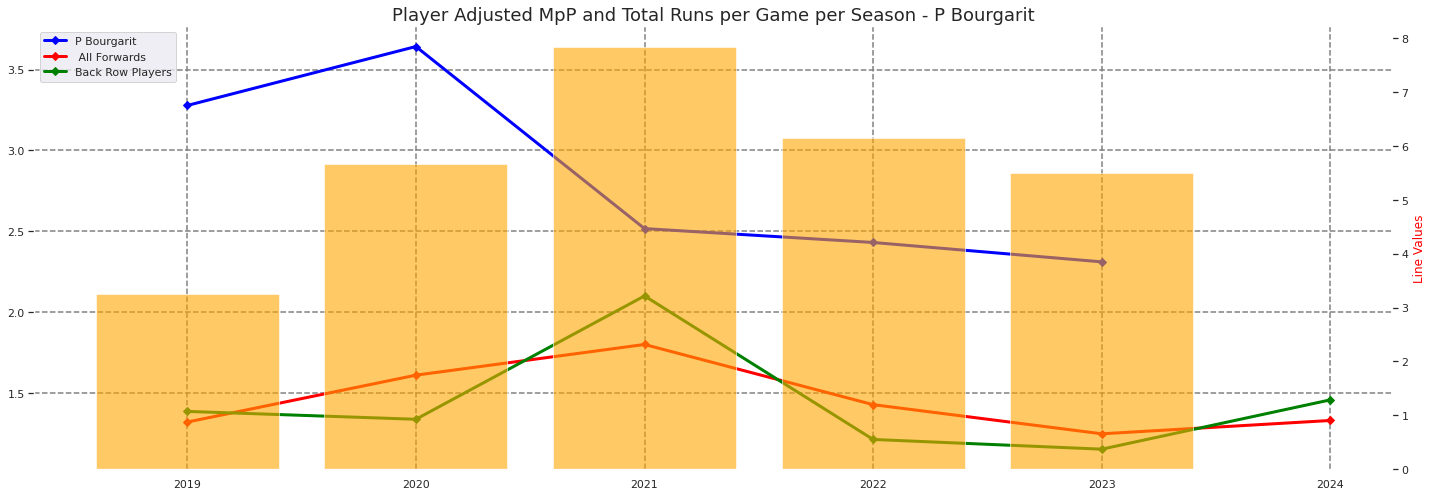

In [10]:
fig, axes = plt.subplots(1, 1,  figsize=(20, 7)) 

player_id = 24593
player_name = lr_forward_avgs[lr_forward_avgs['p_id'] == player_id]['p_name'].iloc[0]
metric_use = 'adj_meters_per_passes'

p_boud = lr_forward_avgs[lr_forward_avgs['p_id'] == player_id]
all_for = lr_forward_overs.groupby('season')['meters_per_passes', 'adj_meters_per_passes'].mean().reset_index()
back_row = lr_df[lr_df['off_position'].isin(['FL', 'N8'])].groupby('season')[
    'meters_per_passes', 'adj_meters_per_passes'
].mean().reset_index()

axes.plot(p_boud['season'], p_boud[metric_use], color='blue', marker='D', linewidth=3.0, zorder=3)
axes.plot(all_for['season'], all_for[metric_use], color='red', marker='D', linewidth=3.0, zorder=3)
axes.plot(back_row['season'], back_row[metric_use], color='green', marker='D', linewidth=3.0, zorder=3)

ax2 = axes.twinx()
axes.patch.set_visible(False)

bars = ax2.bar(p_boud['season'], p_boud['runs_x'], alpha=0.6, color='orange', label='Bar plot', zorder=1)
ax2.grid(False)
# Set the z-order of the bar plot to be lower than the line plot
for bar in bars:
    bar.set_zorder(1)  # Bars behind the grid and line plot
axes.grid(True, which='both', color='grey', linestyle='--', linewidth=1.5, zorder=0)

ax2.set_ylabel('Line Values', color='red')

axes.legend([player_name, ' All Forwards', 'Back Row Players'], loc='upper left')
ax2.patch.set_visible(False)  # Make the secondary y-axis transparent

axes.set_title('Player Adjusted MpP and Total Runs per Game per Season - {}'.format(player_name), fontsize=18)

plt.tight_layout()
plt.show()

NameError: name 'lr_for_cap' is not defined

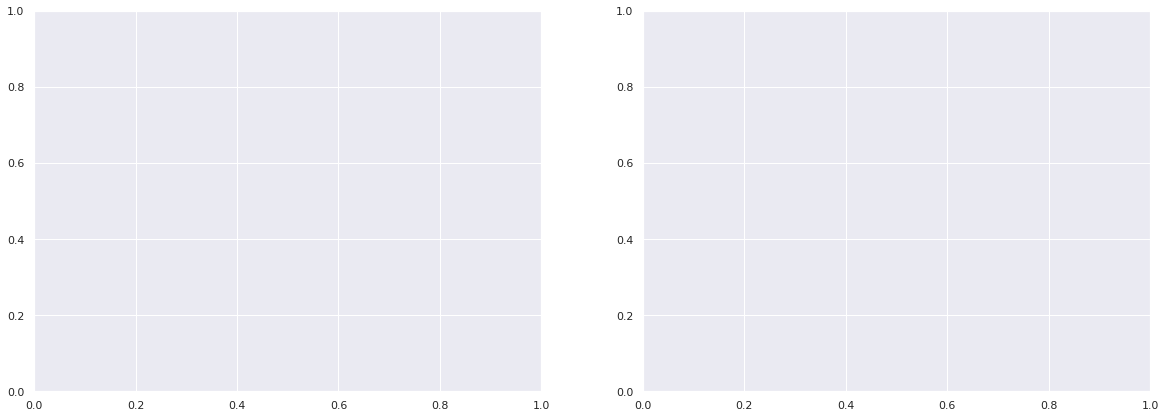

In [11]:
fig, axes = plt.subplots(1, 2,  figsize=(20, 7)) 

lr_for_group = lr_for_cap[['p_id', 'season', 'cap_count']].drop_duplicates().groupby('season')['cap_count'].sum().reset_index()
lr_back_group = lr_back_cap[['p_id', 'season', 'cap_count']].drop_duplicates().groupby('season')['cap_count'].sum().reset_index()

lr_for_x_lim, lr_back_x_lim = get_min_max_lims(lr_for_group['cap_count']), get_min_max_lims(lr_back_group['cap_count'])

axes[0].bar(lr_for_group['season'], lr_for_group['cap_count'], color=(1.0, 0.74, 0.0))
axes[1].bar(lr_back_group['season'], lr_back_group['cap_count'], color=(1.0, 0.74, 0.0))

axes[0].set_ylim((0, lr_for_x_lim[1]))
axes[1].set_ylim((0, lr_for_x_lim[1]))

# axes[0].xticks(rotation=80)

axes[0].set_xlabel('Year', fontsize=10)
axes[0].set_ylabel('# of International Caps', fontsize=10)
axes[0].set_title("La Rochelle International Caps of Forward Players by Year", fontsize=12, fontweight='bold')

axes[1].set_xlabel('Year', fontsize=10)
axes[1].set_ylabel('# of International Caps', fontsize=10)
axes[1].set_title("La Rochelle International Caps of Back Players by Year", fontsize=12, fontweight='bold')

# output_name = "La_Rochelle_team_caps.png"
# plt.savefig('../{}'.format(output_name), dpi=300, facecolor='white', bbox_inches='tight')

# plt.xticks(rotation=80)
plt.tight_layout()
plt.show()

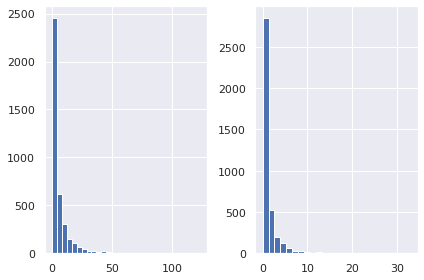

In [10]:
urc_2024 = data_concat[(data_concat['season'] == 2024) & (data_concat['league'] == 'URC')]

fig, axs = plt.subplots(1,2, tight_layout=True)

axs[0].hist(urc_2024['meters_per_passes'], bins=30)
axs[1].hist(urc_2024['adj_meters_per_passes'], bins=25)
plt.show()


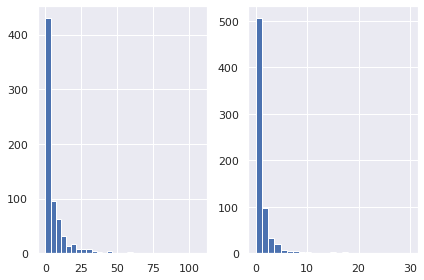

In [11]:
six_nat_2024 = six_nat_player_concat[(six_nat_player_concat['season'] == 2024)]

fig, axs = plt.subplots(1,2, tight_layout=True)

axs[0].hist(six_nat_2024['meters_per_passes'], bins=30)
axs[1].hist(six_nat_2024['adj_meters_per_passes'], bins=25)
plt.show()
